In [1]:
#Importing the Libraries

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
#Importing the Dataset

data=pd.read_csv("loan_approval_dataset.csv")

In [3]:
data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
data.shape

(4269, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [6]:
data.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [7]:
# Check for NULL value

data.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [8]:
# Check for Duplicated value

data.duplicated().sum()

0

In [9]:
data.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

In [10]:
# Removing the extra spaces from the columns name

data.columns = data.columns.str.replace(' ', '') 

In [11]:
data.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [12]:
# check for the data types of the column

data.dtypes

loan_id                      int64
no_of_dependents             int64
education                   object
self_employed               object
income_annum                 int64
loan_amount                  int64
loan_term                    int64
cibil_score                  int64
residential_assets_value     int64
commercial_assets_value      int64
luxury_assets_value          int64
bank_asset_value             int64
loan_status                 object
dtype: object

In [13]:
# Drop unnecessary columns

data.drop(['loan_id','no_of_dependents'],axis=1,inplace=True)

In [14]:
data['education'].unique()

array([' Graduate', ' Not Graduate'], dtype=object)

In [15]:
data['self_employed'].unique()

array([' No', ' Yes'], dtype=object)

In [16]:
data['loan_status'].unique()

array([' Approved', ' Rejected'], dtype=object)

In [17]:
# Replace the values of categorical column with intergers 0/1

data['education'].replace({' Graduate':1,' Not Graduate':0},inplace=True)
data['self_employed'].replace({' No':0,' Yes':1},inplace=True)
data['loan_status'].replace({' Approved':1,' Rejected':0},inplace=True)

In [18]:
data.head()

,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


<Axes: >

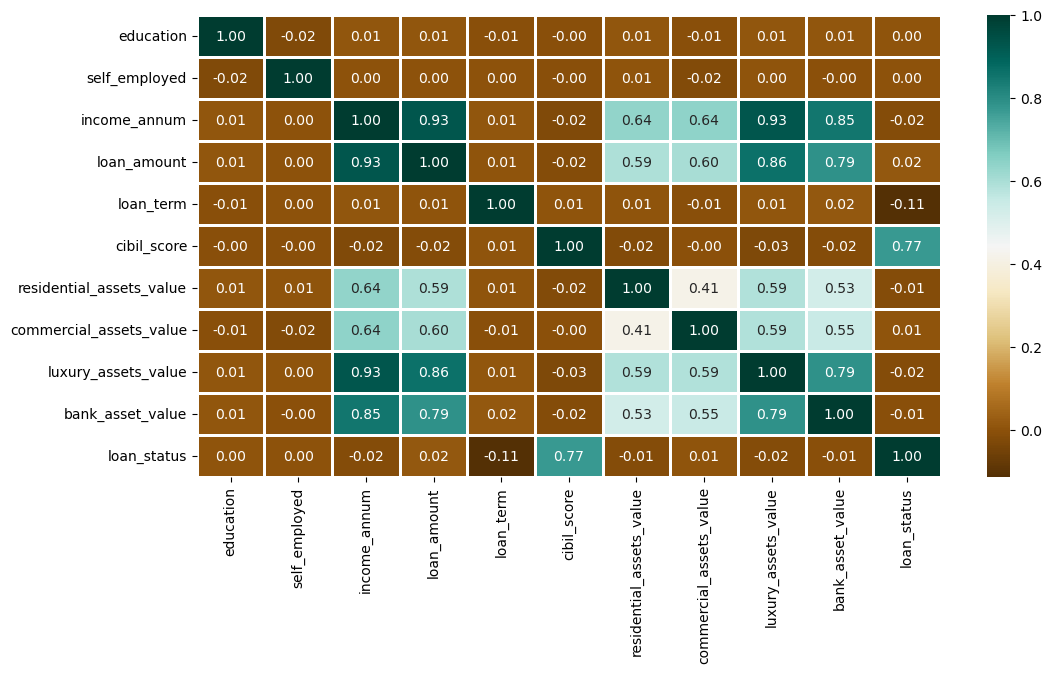

In [19]:
plt.figure(figsize=(12,6)) 
  
sns.heatmap(data.corr(),cmap='BrBG',fmt='.2f', 
            linewidths=2,annot=True)

In [21]:
X=data[['self_employed','income_annum','loan_amount','loan_term','cibil_score']]
y=data.iloc[:,-1]

In [22]:
# Split the dataset into training and testing

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)


In [25]:
# checking the shape of traing and testing dataset

print("x-train shape: ",X_train.shape)
print("x-test shape: ",X_test.shape)
print("y-train shape: ",y_train.shape)
print("x-test shape: ",y_test.shape)

x-train shape:  (2860, 5)
x-test shape:  (1409, 5)
y-train shape:  (2860,)
x-test shape:  (1409,)


## Model train using Naive-Bayes

In [26]:
from sklearn.naive_bayes import GaussianNB

gnb=GaussianNB()
gnb.fit(X_train,y_train)
y_pred=gnb.predict(X_test)

In [27]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7757274662881476

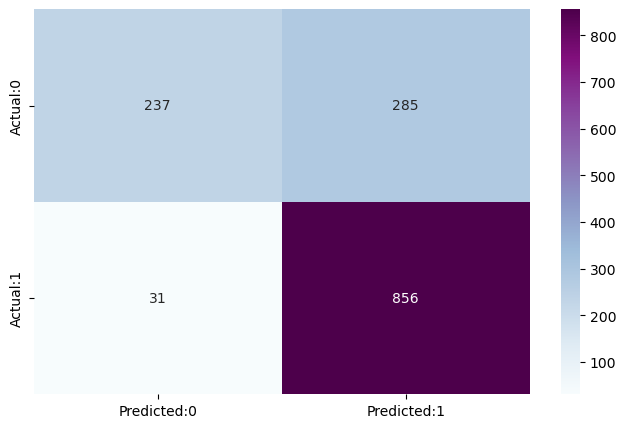

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.88      0.45      0.60       522
           1       0.75      0.97      0.84       887

    accuracy                           0.78      1409
   macro avg       0.82      0.71      0.72      1409
weighted avg       0.80      0.78      0.75      1409



In [28]:
from sklearn.metrics import classification_report,confusion_matrix

cm = confusion_matrix(y_test, y_pred)
conf_matrix = pd.DataFrame(data = cm,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = "BuPu")

plt.show()
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred))

## Model train using Support-Vector-Classifier

In [30]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

svc=SVC()
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}
grid=GridSearchCV(svc,param_grid,refit=True,verbose=3)
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.617 total time=   0.3s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.617 total time=   0.2s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.619 total time=   0.2s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.617 total time=   0.2s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf']},
             verbose=3)

In [31]:
grid.best_params_

{'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}

In [32]:
svc=SVC(C=0.1,gamma=1,kernel='rbf')
svc.fit(X_train,y_train)
y_pred1=svc.predict(X_test)

In [33]:
accuracy_score(y_test, y_pred1)

0.6295244854506742

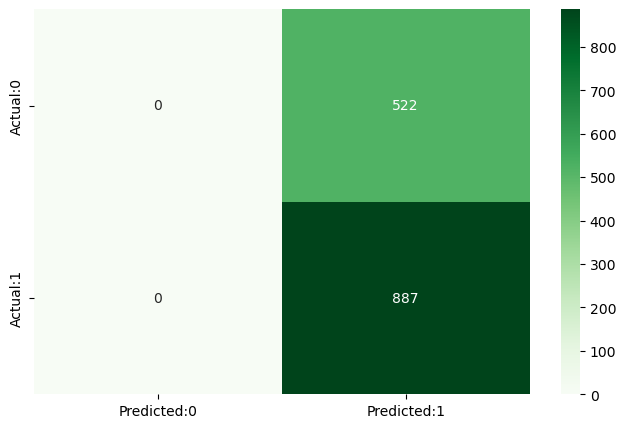

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       522
           1       0.63      1.00      0.77       887

    accuracy                           0.63      1409
   macro avg       0.31      0.50      0.39      1409
weighted avg       0.40      0.63      0.49      1409



C:\Users\aeccs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\aeccs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\aeccs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [34]:
cm1 = confusion_matrix(y_test, y_pred1)
conf_matrix1 = pd.DataFrame(data = cm1,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix1, annot = True, fmt = 'd', cmap = "Greens")

plt.show()
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred1))

## Model train using KNN-Classifier

In [35]:
from sklearn.neighbors import KNeighborsClassifier 

knn = KNeighborsClassifier(n_neighbors=3) 
knn.fit(X_train, y_train) 
y_pred2 = knn.predict(X_test)

In [36]:
accuracy_score(y_test, y_pred2)

0.5933286018452804

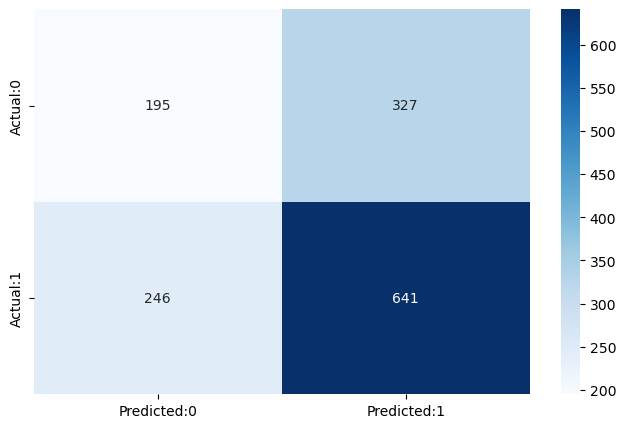

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.44      0.37      0.40       522
           1       0.66      0.72      0.69       887

    accuracy                           0.59      1409
   macro avg       0.55      0.55      0.55      1409
weighted avg       0.58      0.59      0.59      1409



In [37]:
cm2 = confusion_matrix(y_test, y_pred2)
conf_matrix2 = pd.DataFrame(data = cm2,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix2, annot = True, fmt = 'd', cmap = "Blues")

plt.show()
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred2))

## Model train using Random-Forest_Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier 

rfc = RandomForestClassifier(n_estimators = 7, 
                             criterion = 'entropy', 
                             random_state =7) 
rfc.fit(X_train, y_train)
y_pred3 = rfc.predict(X_test)

In [40]:
accuracy_score(y_test, y_pred3)

0.9751596877217885

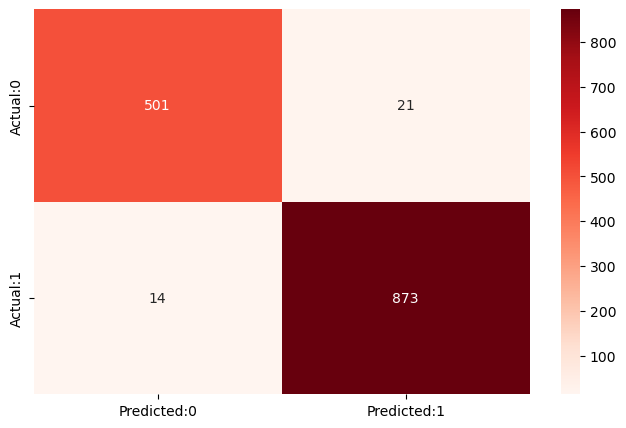

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       522
           1       0.98      0.98      0.98       887

    accuracy                           0.98      1409
   macro avg       0.97      0.97      0.97      1409
weighted avg       0.98      0.98      0.98      1409



In [41]:
cm3 = confusion_matrix(y_test, y_pred3)
conf_matrix3 = pd.DataFrame(data = cm3,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix3, annot = True, fmt = 'd', cmap = "Reds")

plt.show()
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred3))

## Model train Using Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression 

lc = LogisticRegression() 
lc.fit(X_train, y_train) 
y_pred4 = lc.predict(X_test)

In [43]:
accuracy_score(y_test,y_pred4)

0.6295244854506742

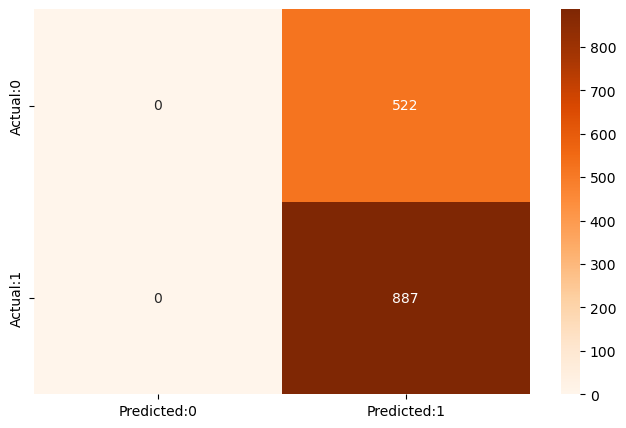

The details for confusion matrix is =
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       522
           1       0.63      1.00      0.77       887

    accuracy                           0.63      1409
   macro avg       0.31      0.50      0.39      1409
weighted avg       0.40      0.63      0.49      1409



C:\Users\aeccs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\aeccs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\aeccs\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [44]:
cm4 = confusion_matrix(y_test, y_pred4)
conf_matrix4 = pd.DataFrame(data = cm4,
                           columns = ['Predicted:0', 'Predicted:1'],
                           index =['Actual:0', 'Actual:1'])

plt.figure(figsize = (8, 5))
sns.heatmap(conf_matrix4, annot = True, fmt = 'd', cmap = "Oranges")

plt.show()
print('The details for confusion matrix is =')
print (classification_report(y_test, y_pred4))

## From the above, we can see that RandomForest Classifier perform well with the accuracy of 97 %.

In [45]:
import pickle 
pickle_out = open("classifier.pkl", mode = "wb") 
pickle.dump(rfc, pickle_out) 
pickle_out.close()

## Model Deployment using Streamlit

In [47]:
import streamlit as st
import pickle

# loading the trained model
pickle_in = open('classifier.pkl', 'rb') 
classifier = pickle.load(pickle_in)

# defining the function which will make the prediction using the data which the user inputs 
def prediction(self_employed,income_annum,loan_amount,loan_term,cibil_score):     
    if self_employed == "no":
        self_employed = 0
    else:
        self_employed = 1
        
    loan_amount = loan_amount / 1000

    # Making predictions 
    prediction = classifier.predict([[self_employed,income_annum,loan_amount,loan_term,cibil_score]])

    if prediction == 0:
        prediction = 'Rejected'
    else:
        prediction = 'Approved'
        
    print(prediction)
    return prediction


#this is the main function in which we define our webpage  
def main():       
    #front end elements of the web page 
    html_temp = """ 
    <div style ="background-color:yellow;padding:13px"> 
    <h1 style ="color:black;text-align:center;">Loan Approval Prediction ML App </h1> 
    </div> 
    """

    #display the front end aspect
    st.markdown(html_temp, unsafe_allow_html = True) 

    #following lines create boxes in which user can enter data required to make prediction 
    self_employed = st.selectbox('self_employed',("yes","no"))
    income_annum = st.number_input("Applicants monthly income") 
    loan_amount = st.number_input("Total loan amount")
    loan_term = st.number_input("Total loan_term")
    cibil_score = st.number_input("Enter cibil_score")
    result =""
    #when 'Predict' is clicked, make the prediction and store it 
    if st.button("Predict"): 
        result = prediction(self_employed,income_annum,loan_amount,loan_term,cibil_score) 
    st.success('Your loan is {}'.format(result))
    print(loan_amount)

if __name__=='__main__': 
    main()

0.0
